## Configuracion del entorno

Este notebook corria originalmente en Google Colab. Para ejecutarlo localmente en
este repositorio:

1. Crea y activa el entorno virtual del proyecto (`.venv` en la raiz del repo) e
   instala las dependencias listadas en `requirements.txt`.
2. Copia `.env.example` a `.env` (en la raiz del repo) y coloca ahi tu `HF_TOKEN`
   de Hugging Face (necesario para los datasets/modelos con acceso restringido).
3. Ejecuta las celdas en orden desde este punto.

Las carpetas de datos (`training/data/raw` para entrada, `training/data/processed`
para salida) y de modelos (`model_artifacts/`) ya existen en el repo y reemplazan
el uso de Google Drive del notebook original.

In [1]:
import os
from pathlib import Path

# Se asume que el notebook se ejecuta con su propio directorio como cwd
# (comportamiento por defecto de Jupyter/VS Code al abrir un .ipynb).
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

RAW_DIR = PROJECT_ROOT / "training" / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "training" / "data" / "processed"
MODEL_ARTIFACTS_DIR = PROJECT_ROOT / "model_artifacts"

for carpeta in (RAW_DIR, PROCESSED_DIR, MODEL_ARTIFACTS_DIR):
    carpeta.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT:           {PROJECT_ROOT}")
print(f"RAW_DIR (entrada):      {RAW_DIR}")
print(f"PROCESSED_DIR (salida): {PROCESSED_DIR}")
print(f"MODEL_ARTIFACTS_DIR:    {MODEL_ARTIFACTS_DIR}")

PROJECT_ROOT:           c:\Users\unvat\Downloads\treasureflow-nlp
RAW_DIR (entrada):      c:\Users\unvat\Downloads\treasureflow-nlp\training\data\raw
PROCESSED_DIR (salida): c:\Users\unvat\Downloads\treasureflow-nlp\training\data\processed
MODEL_ARTIFACTS_DIR:    c:\Users\unvat\Downloads\treasureflow-nlp\model_artifacts


### Autenticacion en Hugging Face

In [2]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv(PROJECT_ROOT / ".env")

hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(hf_token)
    print("Sesion de Hugging Face iniciada.")
else:
    print("HF_TOKEN no esta definido (revisa tu archivo .env). "
          "Continuo sin iniciar sesion; solo hace falta para datasets/modelos con acceso restringido.")

c:\Users\unvat\Downloads\treasureflow-nlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Sesion de Hugging Face iniciada.


## **Conseguir datasets de HuggingFace**

In [ ]:
"""
Script para descargar y preprocesar datasets publicos de discurso ofensivo
en espanol, dejandolos organizados para construir el dataset de fine-tuning
multilabel (grosero / amenaza / inapropiado).

Requisitos previos:
    pip install datasets huggingface_hub pandas

Antes de correr esto necesitas autenticarte con tu token de HuggingFace
(el mismo con el que solicitaste acceso a los datasets). En este notebook
eso se hace en la celda de login() de arriba, que lee HF_TOKEN desde el
archivo .env.

IMPORTANTE: este script NO clasifica automaticamente amenazas ni doble
sentido -- eso requiere revision manual (ver seccion "REVISION MANUAL"
al final). Lo que si hace es dejarte los datos ya separados en carpetas
candidatas para que esa revision sea rapida.
"""

import os
import pandas as pd
from datasets import load_dataset

# Carpeta de salida: datos de entrada del pipeline (raw)
OUTPUT_DIR = str(RAW_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)


def guardar_csv(df: pd.DataFrame, nombre: str):
    ruta = os.path.join(OUTPUT_DIR, nombre)
    df.to_csv(ruta, index=False, encoding="utf-8")
    print(f"  -> Guardado: {ruta} ({len(df)} filas)")


# ---------------------------------------------------------------------------
# 1. OFFENDES
# ---------------------------------------------------------------------------
print("\n=== Descargando OffendES ===")
try:
    # Usamos la rama de parquet auto-generada por HuggingFace, ya que este
    # dataset usa un script de carga y no archivos CSV sueltos con nombres
    # predecibles -- pedir el parquet evita depender de ejecutar ese script.
    offendes = load_dataset("fmplaza/offendes", revision="refs/convert/parquet")
except Exception as e:
    print(f"Fallo con refs/convert/parquet ({e}), reintentando con trust_remote_code...")
    offendes = load_dataset("fmplaza/offendes", trust_remote_code=True)

# Unimos todos los splits en un solo DataFrame para trabajar mas comodo
df_offendes = pd.concat(
    [offendes[split].to_pandas() for split in offendes.keys()],
    ignore_index=True,
)

# IMPORTANTE: al venir de la rama de parquet auto-convertida, la columna
# 'label' llega como enteros (tipo ClassLabel), no como los strings
# originales 'NO'/'NOE'/'OFP'/'OFG'. Recuperamos el mapeo int -> nombre
# desde las features del dataset y lo aplicamos antes de filtrar.
label_feature = offendes["train"].features["label"]
id2label = {i: nombre for i, nombre in enumerate(label_feature.names)}
print(f"Mapeo de etiquetas detectado: {id2label}")
df_offendes["label"] = df_offendes["label"].map(id2label)

print(f"Total de filas en OffendES: {len(df_offendes)}")
print("Distribucion de etiquetas:")
print(df_offendes["label"].value_counts())

# Separacion por categoria segun el mapeo que definimos:
# OFP / OFG -> candidatos a "grosero" (revisar si alguno es amenaza real)
# NOE       -> negativos "dificiles" (groserias sin intencion ofensiva)
# NO        -> negativos puros
candidatos_grosero = df_offendes[df_offendes["label"].isin(["OFP", "OFG"])].copy()
negativos_dificiles = df_offendes[df_offendes["label"] == "NOE"].copy()
negativos_puros = df_offendes[df_offendes["label"] == "NO"].copy()

# Renombramos la columna de texto a un nombre estandar para todo el pipeline
for df_tmp in (candidatos_grosero, negativos_dificiles, negativos_puros):
    df_tmp.rename(columns={"comment": "texto"}, inplace=True)

guardar_csv(candidatos_grosero, "offendes_candidatos_grosero.csv")
guardar_csv(negativos_dificiles, "offendes_negativos_dificiles_NOE.csv")
guardar_csv(negativos_puros, "offendes_negativos_puros.csv")


# ---------------------------------------------------------------------------
# 2. SPANISH HATE SPEECH SUPERSET
# ---------------------------------------------------------------------------
print("\n=== Descargando Spanish Hate Speech Superset ===")
superset = load_dataset("manueltonneau/spanish-hate-speech-superset")
df_superset = superset["train"].to_pandas()
print(f"Total de filas en el superset: {len(df_superset)}")
print("Distribucion de labels (1 = odio, 0 = no odio):")
print(df_superset["labels"].value_counts())
print("Distribucion por sub-dataset de origen:")
print(df_superset["dataset"].value_counts())

# Filtramos primero a los sub-datasets mas cercanos a espanol
# latinoamericano/mexicano, ya que el superset mezcla variantes de Espana
# y otros paises. Ajusta esta lista si quieres incluir mas/menos fuentes.
fuentes_relevantes = ["chileno", "homomex"]
df_superset_filtrado = df_superset[df_superset["dataset"].isin(fuentes_relevantes)].copy()
print(f"\nFilas tras filtrar por fuentes {fuentes_relevantes}: {len(df_superset_filtrado)}")

candidatos_odio = df_superset_filtrado[df_superset_filtrado["labels"] == 1].copy()
negativos_superset = df_superset_filtrado[df_superset_filtrado["labels"] == 0].copy()

candidatos_odio.rename(columns={"text": "texto"}, inplace=True)
negativos_superset.rename(columns={"text": "texto"}, inplace=True)

guardar_csv(candidatos_odio, "superset_candidatos_odio_o_amenaza.csv")
guardar_csv(negativos_superset, "superset_negativos.csv")

# Ademas del pool filtrado por fuente (chileno/homomex), guardamos tambien
# el pool COMPLETO (todas las fuentes: hateval, haternet, hascosva,
# misocorpus incluidos) -- esto es porque para AMENAZA especificamente el
# regionalismo importa menos que tener suficiente volumen para encontrar
# casos reales, que ya vimos que son escasos incluso filtrando por fuente.
candidatos_odio_completo = df_superset[df_superset["labels"] == 1].copy()
candidatos_odio_completo.rename(columns={"text": "texto"}, inplace=True)
guardar_csv(candidatos_odio_completo, "superset_candidatos_odio_TODAS_FUENTES.csv")


# ---------------------------------------------------------------------------
# 3. Muestra para revision manual (estratificada por fuente, no azar puro)
# ---------------------------------------------------------------------------
print("\n=== Generando muestras para revision manual ===")

# Tomamos una muestra estratificada por 'dataset' (chileno/homomex) de los
# candidatos "odio" del superset, para no depender de que el azar puro nos
# deje una muestra dominada por una sola fuente. Aumentamos el tamano a 220
# (en vez de 100) porque no todo "odio" es AMENAZA real -- es probable que
# una fraccion buena de estas filas termine siendo solo GROSERIA/insulto
# tras tu revision, asi que conviene partir de una muestra mas grande para
# no quedarte corto del minimo de ~30-50 ejemplos de amenaza.
TAMANO_MUESTRA = 220

if len(candidatos_odio) > 0:
    # Proporcion de cada fuente dentro del pool de candidatos
    proporciones = candidatos_odio["dataset"].value_counts(normalize=True)
    partes = []
    for fuente, proporcion in proporciones.items():
        n_fuente = max(1, round(TAMANO_MUESTRA * proporcion))
        subset_fuente = candidatos_odio[candidatos_odio["dataset"] == fuente]
        n_fuente = min(n_fuente, len(subset_fuente))  # no pedir mas de lo que hay
        partes.append(subset_fuente.sample(n=n_fuente, random_state=42))

    muestra_revision = pd.concat(partes, ignore_index=True)
    muestra_revision = muestra_revision.sample(frac=1, random_state=42).reset_index(drop=True)  # mezclar orden

    muestra_revision = muestra_revision[["texto", "dataset"]].copy()
    muestra_revision["es_grosero"] = ""       # completar a mano: 1 o 0
    muestra_revision["es_amenaza"] = ""       # completar a mano: 1 o 0
    muestra_revision["es_inapropiado"] = ""   # completar a mano: 1 o 0 (poco esperado aqui, pero dejalo disponible)

    print(f"Muestra generada: {len(muestra_revision)} filas")
    print("Distribucion por fuente en la muestra:")
    print(muestra_revision["dataset"].value_counts())

    guardar_csv(muestra_revision, "REVISAR_muestra_para_etiquetar.csv")

print("\nListo. Revisa la carpeta:", OUTPUT_DIR)
print("""
REVISION MANUAL (siguiente paso, fuera de este script):

1. Abre 'REVISAR_muestra_para_etiquetar.csv' y llena a mano las columnas
   es_amenaza / es_grosero / es_inapropiado con 1 o 0 para cada fila.
   Esta es tu fuente principal de ejemplos de AMENAZA, ya que ningun
   dataset publico los distingue automaticamente de groserias.

2. 'offendes_candidatos_grosero.csv' ya lo puedes usar casi directo como
   positivos de 'grosero' (grosero=1, amenaza=0, inapropiado=0), pero vale
   la pena revisar una muestra rapida para descartar casos raros.

3. 'offendes_negativos_dificiles_NOE.csv' son tus mejores negativos:
   groserias sin intencion ofensiva. Etiquetalos como
   grosero=0, amenaza=0, inapropiado=0. Son oro para reducir falsos
   positivos del modelo.

4. Los negativos puros (NO / superset_negativos) van directo como
   grosero=0, amenaza=0, inapropiado=0, sin revision necesaria.

5. La categoria 'inapropiado' (doble sentido) NO tiene representacion en
   estos datasets -- estos ejemplos los vas a tener que escribir a mano
   con tu equipo, como ya haviamos anticipado.

6. Al final, combina todo en un unico CSV con columnas:
   texto, grosero, amenaza, inapropiado
   listo para cargarlo con `datasets` y tokenizar para el fine-tuning.
""")

In [ ]:
"""
Script para filtrar, por palabras clave relacionadas a violencia/amenaza,
el pool de candidatos ya descargado (superset_candidatos_odio_o_amenaza.csv),
con el objetivo de aumentar la probabilidad de encontrar ejemplos reales de
AMENAZA en vez de seguir revisando muestras aleatorias con muy baja tasa
de acierto (como ya se confirmo: ~0 amenazas en 70 filas revisadas al azar).

Este script NO etiqueta nada automaticamente -- solo prioriza y reordena
las filas mas prometedoras para que tu revision manual sea mas eficiente.
La decision final de si algo es amenaza real sigue siendo tuya.

Requisitos previos:
    pip install pandas unidecode
"""

import os
import pandas as pd
from unidecode import unidecode

INPUT_DIR = str(RAW_DIR)
OUTPUT_DIR = str(RAW_DIR)

# ---------------------------------------------------------------------------
# 1. Diccionario de palabras/raices clave relacionadas a violencia explicita
# ---------------------------------------------------------------------------
# Nota: son RAICES (sin conjugar del todo) para capturar variantes por
# conjugacion verbal (matar, mato, mataria, mataria, etc.) usando "contiene".
# Ajusta/agrega terminos si tu revision manual detecta patrones que faltan.
PALABRAS_CLAVE_AMENAZA = [
    "matar", "mato", "mataste", "mataria", "mataremos", "muerete",
    "golpe", "golpear", "pegar", "pegarte", "partir la madre", "partirte",
    "destruir", "destruirte", "acabar contigo", "arruinar tu vida",
    "cuidate", "te va a pesar", "te vas a arrepentir", "vas a pagar",
    "amenaza", "amenazo", "violar", "secuestrar", "quemar tu casa",
    "te voy a", "les voy a", "le voy a", "van a ver", "vas a ver",
    "sangre", "arma", "pistola", "cuchillo", "navaja",
]


def normalizar(texto: str) -> str:
    """Normalizacion simple: minusculas + sin acentos, para que el match
    por palabra clave no falle por tildes o mayusculas."""
    if not isinstance(texto, str):
        return ""
    return unidecode(texto.lower())


def contiene_palabra_clave(texto_normalizado: str, palabras: list) -> list:
    """Devuelve la lista de palabras clave encontradas en el texto (puede
    haber mas de una), para que puedas ver por que se prioriza esa fila."""
    encontradas = [p for p in palabras if normalizar(p) in texto_normalizado]
    return encontradas


def main():
    # Preferimos el pool COMPLETO (todas las fuentes: chileno, homomex,
    # hateval, haternet, hascosva, misocorpus) porque ya confirmamos que
    # las amenazas reales son escasas incluso filtrando por region -- aqui
    # priorizamos volumen sobre regionalismo para esta categoria especifica.
    ruta_pool_completo = os.path.join(INPUT_DIR, "superset_candidatos_odio_TODAS_FUENTES.csv")
    ruta_pool_filtrado = os.path.join(INPUT_DIR, "superset_candidatos_odio_o_amenaza.csv")

    if os.path.exists(ruta_pool_completo):
        ruta_pool = ruta_pool_completo
        print("Usando el pool COMPLETO (todas las fuentes) para maximizar volumen.")
    elif os.path.exists(ruta_pool_filtrado):
        ruta_pool = ruta_pool_filtrado
        print("Aviso: no se encontro el pool completo, usando el pool filtrado "
              "(chileno/homomex). Vuelve a correr preparar_dataset.py actualizado "
              "para generar el pool completo y tener mas candidatos.")
    else:
        print(f"No se encontro ningun pool de candidatos en {INPUT_DIR}. "
              f"Corre primero el script de descarga.")
        return

    df = pd.read_csv(ruta_pool)
    print(f"Pool total de candidatos: {len(df)} filas")

    df["texto_normalizado"] = df["texto"].apply(normalizar)
    df["palabras_encontradas"] = df["texto_normalizado"].apply(
        lambda t: contiene_palabra_clave(t, PALABRAS_CLAVE_AMENAZA)
    )
    df["num_coincidencias"] = df["palabras_encontradas"].apply(len)

    # Nos quedamos solo con filas que tuvieron al menos 1 coincidencia
    df_priorizado = df[df["num_coincidencias"] > 0].copy()
    df_priorizado.sort_values("num_coincidencias", ascending=False, inplace=True)

    print(f"Filas con al menos 1 palabra clave de violencia: {len(df_priorizado)}")
    print("\nPalabras clave mas frecuentes encontradas:")
    todas_las_encontradas = [p for lista in df_priorizado["palabras_encontradas"] for p in lista]
    print(pd.Series(todas_las_encontradas).value_counts().head(15))

    # Preparamos el CSV final para revision manual, con columnas vacias
    # listas para llenar, igual que el formato que ya venias usando.
    df_salida = df_priorizado[["texto", "dataset", "palabras_encontradas", "num_coincidencias"]].copy()
    df_salida["es_grosero"] = ""
    df_salida["es_amenaza"] = ""
    df_salida["es_inapropiado"] = ""

    ruta_salida = os.path.join(OUTPUT_DIR, "REVISAR_priorizado_por_palabras_clave.csv")
    df_salida.to_csv(ruta_salida, index=False, encoding="utf-8")
    print(f"\n-> Guardado: {ruta_salida} ({len(df_salida)} filas)")

    # Tambien guardamos el resto (sin coincidencias) por si necesitas
    # negativos adicionales mas adelante -- no requieren revision.
    df_sin_coincidencia = df[df["num_coincidencias"] == 0].copy()
    df_sin_coincidencia = df_sin_coincidencia[["texto", "dataset"]].copy()
    ruta_sin = os.path.join(OUTPUT_DIR, "superset_sin_palabras_clave_violencia.csv")
    df_sin_coincidencia.to_csv(ruta_sin, index=False, encoding="utf-8")
    print(f"-> Guardado: {ruta_sin} ({len(df_sin_coincidencia)} filas, utiles como negativos adicionales)")

    print("""
SIGUIENTE PASO:
Abre 'REVISAR_priorizado_por_palabras_clave.csv'. Las filas ya vienen
ordenadas por numero de coincidencias (mas probables primero). Revisa
esta lista en vez de seguir con muestras aleatorias -- deberias encontrar
una proporcion mucho mayor de amenazas reales por fila revisada.

Recuerda: que una fila contenga una palabra clave NO significa
automaticamente que sea amenaza real (ej. "cuidate mucho" es una
despedida amistosa, no una amenaza). La columna 'palabras_encontradas'
es solo para ayudarte a priorizar, la decision sigue siendo tuya.
""")


if __name__ == "__main__":
    main()

## **Combinar datasets**

In [ ]:
"""
Script final: combina todas las fuentes de datos ya etiquetadas en un
unico CSV con columnas (texto, grosero, amenaza, inapropiado, fuente),
listo para tokenizar y usar en el fine-tuning.

Fuentes que combina:
  1. offendes_candidatos_grosero.csv   -> grosero=1 (OFP/OFG)
  2. offendes_negativos_dificiles_NOE.csv -> grosero=1 (Postura A:
     tolerancia cero, ya no se trata como negativo)
  3. offendes_negativos_puros.csv      -> negativo puro
  4. superset_negativos.csv            -> negativo puro
  5. REVISAR_priorizado_por_palabras_clave (ya etiquetado a mano)
  6. moderacion_centros_acopio.csv (dominio especifico, tanda 1)
  7. dataset_moderacion.csv (dominio especifico, tanda 2, otro LLM)
  8. my_dataset_moderacion.csv (ejemplos propios del usuario)
  9. pares_contrastivos_amenaza.csv (regla del "tono", pares contrastivos)

Requisitos previos:
    pip install pandas scikit-learn
"""

import os
import pandas as pd

INPUT_DIR = str(RAW_DIR)
OUTPUT_DIR = str(PROCESSED_DIR)

# Cuantas filas tomar como maximo de cada fuente GRANDE/generica, para no
# ahogar a los ejemplos curados y de dominio especifico. Ajusta estos
# numeros si quieres mas/menos volumen generico.
N_GROSERO_OFFENDES = 200
N_NOE_COMO_GROSERO = 200
N_NEGATIVOS_OFFENDES = 250
N_NEGATIVOS_SUPERSET = 150

RANDOM_STATE = 42


def cargar_y_muestrear(ruta, n, columnas_renombrar=None):
    if not os.path.exists(ruta):
        print(f"  [AVISO] No se encontro {ruta}, se omite esta fuente.")
        return pd.DataFrame(columns=["texto", "grosero", "amenaza", "inapropiado"])
    df = pd.read_csv(ruta)
    if columnas_renombrar:
        df = df.rename(columns=columnas_renombrar)
    if n is not None and len(df) > n:
        df = df.sample(n=n, random_state=RANDOM_STATE)
    return df


def main():
    partes = []

    # 1. Grosero de OffendES (OFP/OFG)
    print("Cargando offendes_candidatos_grosero.csv ...")
    df1 = cargar_y_muestrear(
        os.path.join(INPUT_DIR, "offendes_candidatos_grosero.csv"), N_GROSERO_OFFENDES
    )
    if len(df1) > 0:
        df1 = df1[["texto"]].copy()
        df1["grosero"], df1["amenaza"], df1["inapropiado"] = 1, 0, 0
        df1["fuente"] = "offendes_grosero"
        partes.append(df1)

    # 2. NOE reclasificado como grosero=1 (Postura A: tolerancia cero)
    print("Cargando offendes_negativos_dificiles_NOE.csv (reclasificando a grosero=1) ...")
    df2 = cargar_y_muestrear(
        os.path.join(INPUT_DIR, "offendes_negativos_dificiles_NOE.csv"), N_NOE_COMO_GROSERO
    )
    if len(df2) > 0:
        df2 = df2[["texto"]].copy()
        df2["grosero"], df2["amenaza"], df2["inapropiado"] = 1, 0, 0
        df2["fuente"] = "offendes_NOE_reclasificado"
        partes.append(df2)

    # 3. Negativos puros de OffendES
    print("Cargando offendes_negativos_puros.csv ...")
    df3 = cargar_y_muestrear(
        os.path.join(INPUT_DIR, "offendes_negativos_puros.csv"), N_NEGATIVOS_OFFENDES
    )
    if len(df3) > 0:
        df3 = df3[["texto"]].copy()
        df3["grosero"], df3["amenaza"], df3["inapropiado"] = 0, 0, 0
        df3["fuente"] = "offendes_negativo"
        partes.append(df3)

    # 4. Negativos del superset
    print("Cargando superset_negativos.csv ...")
    df4 = cargar_y_muestrear(
        os.path.join(INPUT_DIR, "superset_negativos.csv"), N_NEGATIVOS_SUPERSET
    )
    if len(df4) > 0:
        df4 = df4[["texto"]].copy()
        df4["grosero"], df4["amenaza"], df4["inapropiado"] = 0, 0, 0
        df4["fuente"] = "superset_negativo"
        partes.append(df4)

    # 5. Tu revision manual (grosero/amenaza reales, prioridad alta -- se
    # incluye COMPLETA, sin muestreo, porque es la fuente mas valiosa)
    print("Cargando REVISAR_priorizado_por_palabras_clave (etiquetado a mano) ...")
    ruta5 = os.path.join(INPUT_DIR, "REVISAR_priorizado_por_palabras_clave.csv")
    if os.path.exists(ruta5):
        df5 = pd.read_csv(ruta5)
        df5 = df5.rename(columns={
            "es_grosero": "grosero",
            "es_amenaza": "amenaza",
            "es_inapropiado": "inapropiado",
        })
        df5 = df5[["texto", "grosero", "amenaza", "inapropiado"]].copy()
        df5["fuente"] = "revision_manual_amenaza"
        partes.append(df5)
    else:
        print(f"  [AVISO] No se encontro {ruta5}, se omite esta fuente.")

    # 6. Dataset de dominio especifico (centros de acopio) -- COMPLETO,
    # es la fuente mas importante para que el modelo entienda tu contexto
    print("Cargando moderacion_centros_acopio.csv (dominio especifico) ...")
    ruta6 = os.path.join(INPUT_DIR, "moderacion_centros_acopio.csv")
    if os.path.exists(ruta6):
        df6 = pd.read_csv(ruta6)
        df6 = df6[["texto", "grosero", "amenaza", "inapropiado"]].copy()
        df6["fuente"] = "dominio_centros_acopio"
        partes.append(df6)
    else:
        print(f"  [AVISO] No se encontro {ruta6}, se omite esta fuente.")

    # 7. Dataset de dominio especifico generado por otro LLM (rondas de
    # amenaza/inapropiado/negativos con diversidad estructural) -- COMPLETO
    print("Cargando dataset_moderacion.csv (tanda adicional, otro LLM) ...")
    ruta7 = os.path.join(INPUT_DIR, "dataset_moderacion.csv")
    if os.path.exists(ruta7):
        df7 = pd.read_csv(ruta7)
        df7 = df7[["texto", "grosero", "amenaza", "inapropiado"]].copy()
        df7["fuente"] = "dominio_llm_tanda2"
        partes.append(df7)
    else:
        print(f"  [AVISO] No se encontro {ruta7}, se omite esta fuente.")

    # 8. Ejemplos redactados a mano por el usuario -- COMPLETO, alta calidad
    print("Cargando my_dataset_moderacion.csv (ejemplos propios) ...")
    ruta8 = os.path.join(INPUT_DIR, "my_dataset_moderacion.csv")
    if os.path.exists(ruta8):
        df8 = pd.read_csv(ruta8)
        df8 = df8[["texto", "grosero", "amenaza", "inapropiado"]].copy()
        df8["fuente"] = "propio_usuario"
        partes.append(df8)
    else:
        print(f"  [AVISO] No se encontro {ruta8}, se omite esta fuente.")

    # 9. Pares contrastivos de amenaza (regla del "tono") -- COMPLETO
    print("Cargando pares_contrastivos_amenaza.csv ...")
    ruta9 = os.path.join(INPUT_DIR, "pares_contrastivos_amenaza.csv")
    if os.path.exists(ruta9):
        df9 = pd.read_csv(ruta9)
        df9 = df9[["texto", "grosero", "amenaza", "inapropiado"]].copy()
        df9["fuente"] = "pares_contrastivos_tono"
        partes.append(df9)
    else:
        print(f"  [AVISO] No se encontro {ruta9}, se omite esta fuente.")

    print("Cargando negativos_casa_y_positivos_nuevos.csv ...")
    ruta10 = os.path.join(INPUT_DIR, "negativos_casa_y_positivos_nuevos.csv")
    if os.path.exists(ruta10):
        df10 = pd.read_csv(ruta10)
        df10 = df10[["texto", "grosero", "amenaza", "inapropiado"]].copy()
        df10["fuente"] = "pares_contrastivos_tono"
        partes.append(df10)
    else:
        print(f"  [AVISO] No se encontro {ruta10}, se omite esta fuente.")

    # ---------------------------------------------------------------------
    # Combinar todo
    # ---------------------------------------------------------------------
    df_final = pd.concat(partes, ignore_index=True)

    # Asegurar tipos correctos (0/1 enteros, no floats ni strings)
    for col in ["grosero", "amenaza", "inapropiado"]:
        df_final[col] = pd.to_numeric(df_final[col], errors="coerce").fillna(0).astype(int)

    # Quitar duplicados exactos de texto (puede pasar entre fuentes)
    antes = len(df_final)
    df_final = df_final.drop_duplicates(subset="texto").reset_index(drop=True)
    print(f"\nFilas antes de quitar duplicados: {antes}, despues: {len(df_final)}")

    # Quitar filas con texto vacio o muy corto (ruido)
    df_final = df_final[df_final["texto"].str.strip().str.len() > 2].reset_index(drop=True)

    # Mezclar el orden (importante: no dejar el dataset agrupado por fuente)
    df_final = df_final.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    # ---------------------------------------------------------------------
    # Reporte de balance final
    # ---------------------------------------------------------------------
    print(f"\n=== DATASET FINAL: {len(df_final)} filas ===")
    print("\nDistribucion por fuente:")
    print(df_final["fuente"].value_counts())
    print("\nPositivos por categoria:")
    print(f"  grosero=1:     {df_final['grosero'].sum()} ({df_final['grosero'].mean()*100:.1f}%)")
    print(f"  amenaza=1:     {df_final['amenaza'].sum()} ({df_final['amenaza'].mean()*100:.1f}%)")
    print(f"  inapropiado=1: {df_final['inapropiado'].sum()} ({df_final['inapropiado'].mean()*100:.1f}%)")
    print(f"\nFilas totalmente negativas (0,0,0): "
          f"{((df_final['grosero']==0)&(df_final['amenaza']==0)&(df_final['inapropiado']==0)).sum()}")

    # ---------------------------------------------------------------------
    # Guardar dataset final (sin la columna 'fuente' para el entrenamiento,
    # pero tambien una version CON fuente para que conserves trazabilidad)
    # ---------------------------------------------------------------------
    ruta_final_completa = os.path.join(OUTPUT_DIR, "dataset_final_CON_fuente.csv")
    df_final.to_csv(ruta_final_completa, index=False, encoding="utf-8")
    print(f"\n-> Guardado (con trazabilidad de fuente): {ruta_final_completa}")

    df_entrenamiento = df_final[["texto", "grosero", "amenaza", "inapropiado"]].copy()
    ruta_final = os.path.join(OUTPUT_DIR, "dataset_final_entrenamiento.csv")
    df_entrenamiento.to_csv(ruta_final, index=False, encoding="utf-8")
    print(f"-> Guardado (listo para tokenizar/entrenar): {ruta_final}")

    print("""
SIGUIENTE PASO SUGERIDO:
Este archivo ya esta listo para el split train/validation/test antes del
fine-tuning. Si el balance de categorias (arriba) se ve muy desigual
(ej. inapropiado con un porcentaje mucho menor que las otras dos),
considera ajustar los N_* al inicio del script para incluir menos
generico y asi subir el peso relativo de las categorias mas escasas,
o generar mas ejemplos de esa categoria especifica antes de continuar.
""")


if __name__ == "__main__":
    main()

## **Aplicar split estratificado**

In [ ]:
"""
Divide dataset_final_entrenamiento.csv en train/validation/test, cuidando
que las categorias minoritarias (amenaza, inapropiado) queden
representadas en los tres conjuntos -- un split aleatorio simple corre
el riesgo de dejar validation/test sin ejemplos de esas categorias, dado
lo pocos que son (61 y 33 respectivamente).

Estrategia: como sklearn no soporta estratificacion nativa para
multilabel, se construye una columna auxiliar "estrato" que resume el
caso mas "raro"/prioritario de cada fila (inapropiado > amenaza >
grosero > negativo) y se estratifica sobre esa columna. No es perfecto
para las pocas filas donde se combinan 2+ categorias a la vez, pero
garantiza cobertura minima de cada categoria en los tres splits, que es
lo que realmente importa para poder evaluar el modelo despues.

Requisitos previos:
    pip install pandas scikit-learn
"""

import os
import pandas as pd
from sklearn.model_selection import train_test_split

INPUT_DIR = str(PROCESSED_DIR)
OUTPUT_DIR = str(PROCESSED_DIR)

# Proporciones del split. 70/15/15 es un punto de partida razonable para
# un dataset de este tamano (~1,100 filas).
PROP_TRAIN = 0.70
PROP_VAL = 0.15
PROP_TEST = 0.15

RANDOM_STATE = 42


def construir_estrato(row):
    """Prioriza la categoria mas escasa para definir el 'grupo' de
    estratificacion de cada fila. Si una fila tiene varias etiquetas
    activas, se estratifica por la mas rara para asegurar que las
    categorias minoritarias no se pierdan en el split."""
    if row["inapropiado"] == 1:
        return "inapropiado"
    if row["amenaza"] == 1:
        return "amenaza"
    if row["grosero"] == 1:
        return "grosero"
    return "negativo"


def reportar_balance(nombre, df):
    total = len(df)
    print(f"\n--- {nombre}: {total} filas ---")
    print(f"  grosero=1:     {df['grosero'].sum():>4} ({df['grosero'].mean()*100:.1f}%)")
    print(f"  amenaza=1:     {df['amenaza'].sum():>4} ({df['amenaza'].mean()*100:.1f}%)")
    print(f"  inapropiado=1: {df['inapropiado'].sum():>4} ({df['inapropiado'].mean()*100:.1f}%)")


def main():
    ruta_entrada = os.path.join(INPUT_DIR, "dataset_final_entrenamiento.csv")
    if not os.path.exists(ruta_entrada):
        print(f"No se encontro {ruta_entrada}. Corre primero la celda de combinar dataset final.")
        return

    df = pd.read_csv(ruta_entrada)
    print(f"Dataset de entrada: {len(df)} filas")

    df["estrato"] = df.apply(construir_estrato, axis=1)
    print("\nDistribucion de estratos (categoria mas rara por fila):")
    print(df["estrato"].value_counts())

    # Verificamos que cada estrato tenga al menos unas pocas filas, o el
    # split estratificado va a fallar. Si algun estrato tiene muy pocas
    # filas, avisamos (aunque con 33 de inapropiado deberia alcanzar).
    conteo_estratos = df["estrato"].value_counts()
    estrato_minimo = conteo_estratos.min()
    if estrato_minimo < 10:
        print(f"\n[AVISO] El estrato mas pequeno tiene solo {estrato_minimo} filas. "
              f"El split igual funcionara, pero revisa que val/test no queden con 0-1 ejemplos.")

    # --- Split 1: separamos TRAIN del resto (val+test) ---
    prop_resto = PROP_VAL + PROP_TEST
    df_train, df_resto = train_test_split(
        df,
        test_size=prop_resto,
        stratify=df["estrato"],
        random_state=RANDOM_STATE,
    )

    # --- Split 2: dividimos el resto en VALIDATION y TEST ---
    prop_test_relativa = PROP_TEST / prop_resto  # proporcion de test DENTRO del resto
    df_val, df_test = train_test_split(
        df_resto,
        test_size=prop_test_relativa,
        stratify=df_resto["estrato"],
        random_state=RANDOM_STATE,
    )

    # Quitamos la columna auxiliar antes de guardar
    for d in (df_train, df_val, df_test):
        d.drop(columns=["estrato"], inplace=True)

    # --- Reporte de balance en cada split ---
    reportar_balance("TRAIN", df_train)
    reportar_balance("VALIDATION", df_val)
    reportar_balance("TEST", df_test)

    # --- Guardar ---
    ruta_train = os.path.join(OUTPUT_DIR, "train.csv")
    ruta_val = os.path.join(OUTPUT_DIR, "validation.csv")
    ruta_test = os.path.join(OUTPUT_DIR, "test.csv")

    df_train.to_csv(ruta_train, index=False, encoding="utf-8")
    df_val.to_csv(ruta_val, index=False, encoding="utf-8")
    df_test.to_csv(ruta_test, index=False, encoding="utf-8")

    print(f"\n-> Guardado: {ruta_train} ({len(df_train)} filas)")
    print(f"-> Guardado: {ruta_val} ({len(df_val)} filas)")
    print(f"-> Guardado: {ruta_test} ({len(df_test)} filas)")

    print("""
SIGUIENTE PASO:
Estos tres archivos (train.csv, validation.csv, test.csv) estan listos
para cargarse con la libreria `datasets` de HuggingFace y tokenizarse
para el fine-tuning. Revisa arriba que 'amenaza' e 'inapropiado' tengan
al menos unos pocos ejemplos en validation y test -- si alguno quedo en
0, considera bajar PROP_VAL/PROP_TEST o revisar el balance del dataset
combinado antes de continuar.
""")


if __name__ == "__main__":
    main()

## **Cargar datasets** (Entrenamiento, validación y test)

In [2]:
from datasets import load_dataset

DATASET_DIR = str(PROCESSED_DIR)

data_files = {
    "train": f"{DATASET_DIR}/train.csv",
    "validation": f"{DATASET_DIR}/validation.csv",
    "test": f"{DATASET_DIR}/test.csv",
    "test_2": f"{DATASET_DIR}/validacion_externa_moderacion_completo.csv"
}
dataset = load_dataset("csv", data_files=data_files)

# Construimos la columna 'labels' como vector [grosero, amenaza, inapropiado]
# porque asi es como el modelo de HuggingFace espera las etiquetas multilabel.
LABEL_COLUMNS = ["grosero", "amenaza", "inapropiado"]

def construir_labels(ejemplo):
    ejemplo["labels"] = [float(ejemplo[col]) for col in LABEL_COLUMNS]
    return ejemplo

dataset = dataset.map(construir_labels)
print(dataset)
print(dataset["train"][0])

c:\Users\unvat\Downloads\treasureflow-nlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['texto', 'grosero', 'amenaza', 'inapropiado', 'labels'],
        num_rows: 1039
    })
    validation: Dataset({
        features: ['texto', 'grosero', 'amenaza', 'inapropiado', 'labels'],
        num_rows: 223
    })
    test: Dataset({
        features: ['texto', 'grosero', 'amenaza', 'inapropiado', 'labels'],
        num_rows: 223
    })
    test_2: Dataset({
        features: ['texto', 'grosero', 'amenaza', 'inapropiado', 'labels'],
        num_rows: 500
    })
})
{'texto': 'El personal está disponible toda la noche por si llegas tarde con tu material, muy buen horario.', 'grosero': 0, 'amenaza': 0, 'inapropiado': 0, 'labels': [0.0, 0.0, 0.0]}


## **Tokenización**

In [3]:
# IMPORTANT: If you encounter 'RuntimeError: generic_type: cannot initialize type "RpcBackendOptions"',
# it means torch was reinstalled in a live session. Please RESTART THE KERNEL (Kernel -> Restart Kernel)
# and then run this cell again from scratch.

import os
import torch


from transformers import AutoTokenizer

# Partimos del modelo ya adaptado a hate speech en espanol (Ruta A que
# definimos), en vez de BETO puro -- ya tiene nocion previa de toxicidad.
MODEL_NAME = "piuba-bigdata/beto-contextualized-hate-speech"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenizar(ejemplo):
    return tokenizer(ejemplo["texto"], truncation=True, padding="max_length", max_length=128)

dataset_tokenizado = dataset.map(tokenizar, batched=True)

# Limpiamos columnas que el modelo no necesita, dejamos solo lo indispensable
columnas_a_quitar = ["texto", "fuente"] + LABEL_COLUMNS
columnas_a_quitar = [c for c in columnas_a_quitar if c in dataset_tokenizado["train"].column_names]
dataset_tokenizado = dataset_tokenizado.remove_columns(columnas_a_quitar)
dataset_tokenizado.set_format("torch")

Map: 100%|██████████| 223/223 [00:00<00:00, 2289.43 examples/s]


## **Cargar modelo configurado para multilabel**

In [4]:
import torch
from transformers import AutoModelForSequenceClassification, set_seed

set_seed(42)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLUMNS),
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True,  # el head original no coincide con tus 3 etiquetas, se reinicializa
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at piuba-bigdata/beto-contextualized-hate-speech and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([9]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([9, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## **Pesos por clase** (compensación de pesos)

In [5]:
import numpy as np
from torch.nn import BCEWithLogitsLoss
from transformers import Trainer

train_labels = np.array(dataset["train"]["labels"])
n_total = len(train_labels)
n_positivos = train_labels.sum(axis=0)
pos_weight_crudo = (n_total - n_positivos) / n_positivos

TOPES_POR_CATEGORIA = {                                     # <- aqui defines el limite maximo
    "grosero": 3.0,
    "amenaza": 8.0,        # se queda igual, funciono bien
    "inapropiado": 3.5,
}

# Capamos el peso maximo para que no se vuelva excesivamente agresivo
topes_array = np.array([TOPES_POR_CATEGORIA[col] for col in LABEL_COLUMNS])
pos_weight = np.minimum(pos_weight_crudo, topes_array)   # <- aqui se aplica

pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float)
print("pos_weight crudo:", pos_weight_crudo)
print("pos_weight capado (usado):", pos_weight_tensor)

class TrainerConPesos(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = BCEWithLogitsLoss(pos_weight=pos_weight_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

pos_weight crudo: [ 1.71279373 11.82716049 17.89090909]
pos_weight capado (usado): tensor([1.7128, 8.0000, 3.5000])


## **Métricas de evaluación**

In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits))
    preds = (probs > 0.5).int().numpy()

    resultado = {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
    }
    for i, nombre in enumerate(LABEL_COLUMNS):
        resultado[f"f1_{nombre}"] = f1_score(labels[:, i], preds[:, i], zero_division=0)
        resultado[f"precision_{nombre}"] = precision_score(labels[:, i], preds[:, i], zero_division=0)
        resultado[f"recall_{nombre}"] = recall_score(labels[:, i], preds[:, i], zero_division=0)
    return resultado

## **Configuración del entrenamiento**

In [8]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=str(MODEL_ARTIFACTS_DIR / "checkpoints"),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_inapropiado",
    logging_steps=20,
    report_to="none",
)

## **Entrenamiento**

In [9]:
trainer = TrainerConPesos(
    model=model,
    args=training_args,
    train_dataset=dataset_tokenizado["train"],
    eval_dataset=dataset_tokenizado["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Grosero,Precision Grosero,Recall Grosero,F1 Amenaza,Precision Amenaza,Recall Amenaza,F1 Inapropiado,Precision Inapropiado,Recall Inapropiado
1,0.665200,0.608576,0.372363,0.627803,0.703297,0.621359,0.810127,0.413793,0.500000,0.352941,0.000000,0.000000,0.000000
2,0.501500,0.444818,0.488202,0.656716,0.766667,0.683168,0.873418,0.507463,0.340000,1.000000,0.190476,0.222222,0.166667
3,0.290300,0.370120,0.586160,0.751055,0.811111,0.722772,0.924051,0.736842,0.666667,0.823529,0.210526,0.285714,0.166667
4,0.191200,0.343804,0.647916,0.782222,0.853659,0.823529,0.886076,0.756757,0.700000,0.823529,0.333333,0.333333,0.333333
5,0.149100,0.337440,0.648122,0.782222,0.858896,0.833333,0.886076,0.777778,0.736842,0.823529,0.307692,0.285714,0.333333
6,0.107300,0.340068,0.678058,0.785388,0.853503,0.858974,0.848101,0.823529,0.823529,0.823529,0.357143,0.312500,0.416667


TrainOutput(global_step=390, training_loss=0.33387091220953524, metrics={'train_runtime': 118.6712, 'train_samples_per_second': 52.532, 'train_steps_per_second': 3.286, 'total_flos': 410062261529088.0, 'train_loss': 0.33387091220953524, 'epoch': 6.0})

## **Test**

In [10]:
resultados_test = trainer.evaluate(dataset_tokenizado["test"])
for k, v in resultados_test.items():
    print(f"{k}: {v:.4f}")

eval_loss: 0.4740
eval_f1_macro: 0.6000
eval_f1_micro: 0.7500
eval_f1_grosero: 0.8214
eval_precision_grosero: 0.8118
eval_recall_grosero: 0.8313
eval_f1_amenaza: 0.7059
eval_precision_amenaza: 0.7500
eval_recall_amenaza: 0.6667
eval_f1_inapropiado: 0.2727
eval_precision_inapropiado: 0.2727
eval_recall_inapropiado: 0.2727
eval_runtime: 1.3183
eval_samples_per_second: 169.1540
eval_steps_per_second: 10.6200
epoch: 6.0000


In [11]:
from sklearn.metrics import multilabel_confusion_matrix

predicciones = trainer.predict(dataset_tokenizado["test"])
probs = torch.sigmoid(torch.tensor(predicciones.predictions))
preds = (probs > 0.5).int().numpy()
labels_reales = predicciones.label_ids

matrices = multilabel_confusion_matrix(labels_reales, preds)
for i, nombre in enumerate(LABEL_COLUMNS):
    print(f"\n--- {nombre} ---")
    print("        Pred 0   Pred 1")
    print(f"Real 0  {matrices[i][0][0]:>6}   {matrices[i][0][1]:>6}")
    print(f"Real 1  {matrices[i][1][0]:>6}   {matrices[i][1][1]:>6}")


--- grosero ---
        Pred 0   Pred 1
Real 0     124       16
Real 1      14       69

--- amenaza ---
        Pred 0   Pred 1
Real 0     201        4
Real 1       6       12

--- inapropiado ---
        Pred 0   Pred 1
Real 0     204        8
Real 1       8        3


## Guardar

In [12]:
RUTA_MODELO_FINAL = str(MODEL_ARTIFACTS_DIR / "modelo_moderacion_final")
trainer.save_model(RUTA_MODELO_FINAL)
tokenizer.save_pretrained(RUTA_MODELO_FINAL)
print(f"Modelo guardado en: {RUTA_MODELO_FINAL}")

Modelo guardado en: c:\Users\unvat\Downloads\treasureflow-nlp\model_artifacts\modelo_moderacion_final


## **Probar textos**

In [12]:
from pathlib import Path
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Celda pensada para poder correrse de forma independiente (ej. tras
# reiniciar el kernel), por eso vuelve a resolver las rutas del proyecto.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
MODEL_ARTIFACTS_DIR = PROJECT_ROOT / "model_artifacts"

RUTA_MODELO_FINAL = str(MODEL_ARTIFACTS_DIR / "modelo_moderacion_final")

model = AutoModelForSequenceClassification.from_pretrained(RUTA_MODELO_FINAL)
tokenizer = AutoTokenizer.from_pretrained(RUTA_MODELO_FINAL)

# Mover al mismo device donde vayas a hacer inferencia
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print(f"Modelo cargado desde {RUTA_MODELO_FINAL}, corriendo en: {device}")

Modelo cargado desde c:\Users\unvat\Downloads\treasureflow-nlp\model_artifacts\modelo_moderacion_final, corriendo en: cuda


In [13]:
UMBRALES_POR_CATEGORIA = {
    "grosero": 0.5,
    "amenaza": 0.5,
    "inapropiado": 0.30,  # mas bajo, priorizando recall (tolerancia cero)
}

def moderar_texto(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True,
                        padding="max_length", max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits)[0].cpu().numpy()

    resultado = {}
    for i, nombre in enumerate(LABEL_COLUMNS):
        umbral = UMBRALES_POR_CATEGORIA[nombre]
        resultado[nombre] = {
            "probabilidad": round(float(probs[i]), 4),
            "activado": bool(probs[i] > umbral),
        }

    bloqueado = any(resultado[cat]["activado"] for cat in LABEL_COLUMNS)

    print(f"\nTexto: \"{texto}\"")
    print("-" * 60)
    for nombre in LABEL_COLUMNS:
        marca = "🔴" if resultado[nombre]["activado"] else "🟢"
        print(f"  {marca} {nombre:15s} probabilidad: {resultado[nombre]['probabilidad']:.4f} (umbral: {UMBRALES_POR_CATEGORIA[nombre]})")
    print("-" * 60)
    print(f"  DECISION FINAL: {'❌ BLOQUEAR' if bloqueado else '✅ PERMITIR'}")

    return resultado

In [14]:
ejemplos_de_prueba = [
    "Hola caras de mi pene, les ofresco unas latas de caguama",
    "Buen servicio, me atendieron muy bien, completamente recomendado",
    "Ofrezco unas latas de aluminio, los pueden recoger en mi casa",
    "Pinche lugar de cagada, lo compran muy barato los malditos",
    "Pinches putos no me pagaron, ojala les asalten el establecimiento",
    "Tengo casa sola, vengan traviesos 😘",
    "Pesimo servicio, el personal no me atendio",
    "Pvt0s malditos este lugar no funciona nunca",  # variante ofuscada
]

for texto in ejemplos_de_prueba:
    moderar_texto(texto)


Texto: "Hola caras de mi pene, les ofresco unas latas de caguama"
------------------------------------------------------------
  🔴 grosero         probabilidad: 0.9951 (umbral: 0.5)
  🟢 amenaza         probabilidad: 0.1636 (umbral: 0.5)
  🟢 inapropiado     probabilidad: 0.0377 (umbral: 0.3)
------------------------------------------------------------
  DECISION FINAL: ❌ BLOQUEAR

Texto: "Buen servicio, me atendieron muy bien, completamente recomendado"
------------------------------------------------------------
  🟢 grosero         probabilidad: 0.0120 (umbral: 0.5)
  🟢 amenaza         probabilidad: 0.0211 (umbral: 0.5)
  🔴 inapropiado     probabilidad: 0.7992 (umbral: 0.3)
------------------------------------------------------------
  DECISION FINAL: ❌ BLOQUEAR

Texto: "Ofrezco unas latas de aluminio, los pueden recoger en mi casa"
------------------------------------------------------------
  🟢 grosero         probabilidad: 0.0072 (umbral: 0.5)
  🟢 amenaza         probabilidad: 0.04

## **Búsqueda de hiperparámetros con Optuna**

Explora `tope_amenaza`, `tope_inapropiado`, `learning_rate` y `num_epochs`
entrenando un modelo nuevo por cada combinación y evaluando en
`validation`. `tope_grosero` se deja fijo en 3.0 porque ya se mostró
estable en rondas anteriores.

In [15]:
# Busqueda de hiperparametros con Optuna.
#
# Reutilizamos MODEL_NAME, LABEL_COLUMNS, dataset_tokenizado, compute_metrics
# y la clase TrainerConPesos ya definidos arriba -- aqui solo variamos los
# hiperparametros por trial. Como TrainerConPesos.compute_loss lee la
# variable global `pos_weight_tensor` en cada llamada (no la captura al
# definir la clase), reasignar esa variable global antes de entrenar cada
# trial es suficiente para que cada trial use su propio pos_weight, sin
# tener que tocar la clase.

import optuna

N_TRIALS = 12  # ajustable: numero de combinaciones de hiperparametros a probar

TOPE_GROSERO_FIJO = 3.0  # ya es estable en rondas anteriores, no se optimiza


def objective(trial):
    global pos_weight_tensor

    tope_amenaza = trial.suggest_float("tope_amenaza", 4.0, 15.0)
    tope_inapropiado = trial.suggest_float("tope_inapropiado", 2.0, 8.0)  # antes 15.0, ahora acotado
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    num_epochs = trial.suggest_int("num_epochs", 3, 7)

    # Recalculamos pos_weight para este trial (grosero se queda fijo) y
    # reasignamos la variable global que usa TrainerConPesos.
    topes_trial = {
        "grosero": TOPE_GROSERO_FIJO,
        "amenaza": tope_amenaza,
        "inapropiado": tope_inapropiado,
    }
    topes_array_trial = np.array([topes_trial[col] for col in LABEL_COLUMNS])
    pos_weight_trial = np.minimum(pos_weight_crudo, topes_array_trial)
    pos_weight_tensor = torch.tensor(pos_weight_trial, dtype=torch.float)

    # Modelo nuevo desde cero para cada trial, con semilla fija para que
    # la unica fuente de variacion entre trials sean los hiperparametros.
    set_seed(42)
    modelo_trial = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABEL_COLUMNS),
        problem_type="multi_label_classification",
        ignore_mismatched_sizes=True,
    )

    args_trial = TrainingArguments(
        output_dir=str(MODEL_ARTIFACTS_DIR / "optuna_trials" / f"trial_{trial.number}"),
        eval_strategy="epoch",
        save_strategy="no",  # no necesitamos checkpoints intermedios de la busqueda
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        logging_steps=20,
        report_to="none",
    )

    trainer_trial = TrainerConPesos(
        model=modelo_trial,
        args=args_trial,
        train_dataset=dataset_tokenizado["train"],
        eval_dataset=dataset_tokenizado["validation"],
        compute_metrics=compute_metrics,
    )

    trainer_trial.train()
    resultados = trainer_trial.evaluate()  # evalua sobre validation

    # Guardamos las metricas completas para poder inspeccionarlas despues
    # sin tener que reentrenar el trial.
    trial.set_user_attr("metricas_completas", resultados)

    # Metrica a maximizar: el MINIMO de los 3 F1 por categoria, no el
    # promedio -- ya vimos en rondas anteriores que f1_macro puede
    # esconder una categoria mal atendida.
    metrica_objetivo = min(
        resultados["eval_f1_grosero"],
        resultados["eval_f1_amenaza"],
        resultados["eval_f1_inapropiado"],
    )
    return metrica_objetivo


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)

print("\n=== Mejor combinacion de hiperparametros encontrada ===")
print("best_params:", study.best_params)
print("best_value (minimo de los 3 F1 por categoria en validation):", study.best_value)
print("\nMetricas completas del mejor trial:")
for k, v in study.best_trial.user_attrs["metricas_completas"].items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

[I 2026-07-26 17:30:12,430] A new study created in memory with name: no-name-e39d2536-6a2e-4a47-a612-93e0f8f5d5dc
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at piuba-bigdata/beto-contextualized-hate-speech and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([9]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([9, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Grosero,Precision Grosero,Recall Grosero,F1 Amenaza,Precision Amenaza,Recall Amenaza,F1 Inapropiado,Precision Inapropiado,Recall Inapropiado
1,0.720700,0.718120,0.250235,0.561404,0.639594,0.533898,0.797468,0.111111,1.000000,0.058824,0.000000,0.000000,0.000000
2,0.627600,0.597156,0.502148,0.661017,0.767442,0.709677,0.835443,0.545455,0.562500,0.529412,0.193548,0.157895,0.250000
3,0.474000,0.535105,0.523559,0.674699,0.784091,0.711340,0.873418,0.536585,0.458333,0.647059,0.250000,0.200000,0.333333
4,0.365700,0.515402,0.543963,0.695279,0.802395,0.761364,0.848101,0.571429,0.555556,0.588235,0.258065,0.210526,0.333333


[I 2026-07-26 17:31:19,932] Trial 0 finished with value: 0.25806451612903225 and parameters: {'tope_amenaza': 5.4108636520342275, 'tope_inapropiado': 7.417793851974977, 'learning_rate': 1.4818267083597749e-05, 'num_epochs': 4}. Best is trial 0 with value: 0.25806451612903225.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at piuba-bigdata/beto-contextualized-hate-speech and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([9]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([9, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Grosero,Precision Grosero,Recall Grosero,F1 Amenaza,Precision Amenaza,Recall Amenaza,F1 Inapropiado,Precision Inapropiado,Recall Inapropiado
1,0.707200,0.712795,0.211055,0.550218,0.633166,0.525000,0.797468,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.624200,0.598603,0.445030,0.635193,0.758621,0.694737,0.835443,0.400000,0.625000,0.294118,0.176471,0.136364,0.250000
3,0.480900,0.540774,0.533006,0.685950,0.786517,0.707071,0.886076,0.562500,0.600000,0.529412,0.250000,0.200000,0.333333
4,0.354700,0.512716,0.552753,0.722467,0.821429,0.775281,0.873418,0.606061,0.625000,0.588235,0.230769,0.214286,0.250000
5,0.332600,0.490098,0.573818,0.716814,0.830189,0.825000,0.835443,0.588235,0.588235,0.588235,0.303030,0.238095,0.416667


[I 2026-07-26 17:32:43,529] Trial 1 finished with value: 0.30303030303030304 and parameters: {'tope_amenaza': 4.496512572925522, 'tope_inapropiado': 7.5339728827686, 'learning_rate': 1.2693402948989925e-05, 'num_epochs': 5}. Best is trial 1 with value: 0.30303030303030304.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at piuba-bigdata/beto-contextualized-hate-speech and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([9]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([9, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Grosero,Precision Grosero,Recall Grosero,F1 Amenaza,Precision Amenaza,Recall Amenaza,F1 Inapropiado,Precision Inapropiado,Recall Inapropiado
1,0.682100,0.631701,0.346075,0.604444,0.681081,0.594340,0.797468,0.357143,0.454545,0.294118,0.000000,0.000000,0.000000
2,0.525100,0.462183,0.459506,0.654275,0.760870,0.666667,0.886076,0.500000,0.333333,1.000000,0.117647,0.200000,0.083333
3,0.314100,0.372173,0.545096,0.750000,0.824176,0.728155,0.949367,0.700000,0.608696,0.823529,0.111111,0.166667,0.083333
4,0.209200,0.342762,0.637850,0.771930,0.843373,0.804598,0.886076,0.736842,0.666667,0.823529,0.333333,0.333333,0.333333
5,0.162300,0.337277,0.670461,0.807175,0.878049,0.847059,0.911392,0.800000,0.777778,0.823529,0.333333,0.333333,0.333333
6,0.110000,0.347207,0.649548,0.772093,0.840764,0.846154,0.835443,0.787879,0.812500,0.764706,0.320000,0.307692,0.333333
7,0.073900,0.350171,0.656793,0.788991,0.862500,0.851852,0.873418,0.787879,0.812500,0.764706,0.320000,0.307692,0.333333


[I 2026-07-26 17:44:29,799] Trial 10 finished with value: 0.32 and parameters: {'tope_amenaza': 8.315959815053294, 'tope_inapropiado': 3.1608096740624143, 'learning_rate': 1.7091213386164752e-05, 'num_epochs': 7}. Best is trial 7 with value: 0.4.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at piuba-bigdata/beto-contextualized-hate-speech and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([9]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([9, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Grosero,Precision Grosero,Recall Grosero,F1 Amenaza,Precision Amenaza,Recall Amenaza,F1 Inapropiado,Precision Inapropiado,Recall Inapropiado
1,0.538100,0.513617,0.453102,0.712195,0.787879,0.755814,0.822785,0.571429,0.727273,0.470588,0.000000,0.000000,0.000000
2,0.342500,0.340558,0.675108,0.755187,0.830189,0.825000,0.835443,0.680851,0.533333,0.941176,0.514286,0.391304,0.750000
3,0.154500,0.410435,0.589232,0.786026,0.842697,0.757576,0.949367,0.800000,0.777778,0.823529,0.125000,0.250000,0.083333
4,0.068200,0.507599,0.654890,0.798030,0.857143,0.880000,0.835443,0.774194,0.857143,0.705882,0.333333,0.500000,0.250000
5,0.053200,0.509209,0.664888,0.801887,0.855346,0.850000,0.860759,0.823529,0.823529,0.823529,0.315789,0.428571,0.250000
6,0.023600,0.564575,0.653604,0.796117,0.857143,0.880000,0.835443,0.787879,0.812500,0.764706,0.315789,0.428571,0.250000
7,0.008900,0.583171,0.654242,0.782178,0.834437,0.875000,0.797468,0.812500,0.866667,0.764706,0.315789,0.428571,0.250000


[I 2026-07-26 17:46:26,582] Trial 11 finished with value: 0.3157894736842105 and parameters: {'tope_amenaza': 8.497336403219006, 'tope_inapropiado': 3.621095620738082, 'learning_rate': 4.701115160948478e-05, 'num_epochs': 7}. Best is trial 7 with value: 0.4.



=== Mejor combinacion de hiperparametros encontrada ===
best_params: {'tope_amenaza': 12.687230373995702, 'tope_inapropiado': 4.128288504836338, 'learning_rate': 3.654033597916692e-05, 'num_epochs': 7}
best_value (minimo de los 3 F1 por categoria en validation): 0.4

Metricas completas del mejor trial:
  eval_loss: 0.5910
  eval_f1_macro: 0.6651
  eval_f1_micro: 0.7723
  eval_f1_grosero: 0.8212
  eval_precision_grosero: 0.8611
  eval_recall_grosero: 0.7848
  eval_f1_amenaza: 0.7742
  eval_precision_amenaza: 0.8571
  eval_recall_amenaza: 0.7059
  eval_f1_inapropiado: 0.4000
  eval_precision_inapropiado: 0.5000
  eval_recall_inapropiado: 0.3333
  eval_runtime: 1.0472
  eval_samples_per_second: 212.9540
  eval_steps_per_second: 13.3690
  epoch: 7.0000


## **Entrenamiento final con los mejores hiperparámetros (Optuna)**

Reentrena el modelo desde cero con `study.best_params`, evalúa en TEST y
sobreescribe el modelo final en `model_artifacts/modelo_moderacion_final`.

In [16]:
# Entrenamiento final del modelo usando los mejores hiperparametros
# encontrados por Optuna. Mismo patron de siempre (modelo nuevo desde
# cero + TrainerConPesos), pero esta vez evaluando tambien en TEST y
# sobreescribiendo el modelo final del proyecto.

mejores_params = study.best_params

topes_finales = {
    "grosero": TOPE_GROSERO_FIJO,
    "amenaza": mejores_params["tope_amenaza"],
    "inapropiado": mejores_params["tope_inapropiado"],
}
topes_array_final = np.array([topes_finales[col] for col in LABEL_COLUMNS])
pos_weight_final = np.minimum(pos_weight_crudo, topes_array_final)
pos_weight_tensor = torch.tensor(pos_weight_final, dtype=torch.float)
print("pos_weight final (usado en el reentrenamiento):", pos_weight_tensor)

set_seed(42)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLUMNS),
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True,
)

training_args_final = TrainingArguments(
    output_dir=str(MODEL_ARTIFACTS_DIR / "checkpoints"),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=mejores_params["learning_rate"],
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=mejores_params["num_epochs"],
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_inapropiado",
    logging_steps=20,
    report_to="none",
)

trainer = TrainerConPesos(
    model=model,
    args=training_args_final,
    train_dataset=dataset_tokenizado["train"],
    eval_dataset=dataset_tokenizado["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

resultados_test_final = trainer.evaluate(dataset_tokenizado["test"])
print("\n=== Metricas en TEST (modelo final optimizado) ===")
for k, v in resultados_test_final.items():
    print(f"{k}: {v:.4f}")

RUTA_MODELO_FINAL = str(MODEL_ARTIFACTS_DIR / "modelo_moderacion_final")
trainer.save_model(RUTA_MODELO_FINAL)
tokenizer.save_pretrained(RUTA_MODELO_FINAL)
print(f"\nModelo final (hiperparametros optimizados con Optuna) guardado en: {RUTA_MODELO_FINAL}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at piuba-bigdata/beto-contextualized-hate-speech and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([9]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([9, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


pos_weight final (usado en el reentrenamiento): tensor([ 1.7128, 11.8272,  4.1283])


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Grosero,Precision Grosero,Recall Grosero,F1 Amenaza,Precision Amenaza,Recall Amenaza,F1 Inapropiado,Precision Inapropiado,Recall Inapropiado
1,0.618900,0.575880,0.430867,0.694836,0.776471,0.725275,0.835443,0.516129,0.571429,0.470588,0.000000,0.000000,0.000000
2,0.432200,0.389151,0.595975,0.686347,0.802395,0.761364,0.848101,0.618182,0.447368,1.000000,0.367347,0.243243,0.750000
3,0.182700,0.422204,0.566472,0.747899,0.822222,0.732673,0.936709,0.666667,0.590909,0.764706,0.210526,0.285714,0.166667
4,0.093900,0.440115,0.691377,0.769953,0.826667,0.873239,0.784810,0.764706,0.764706,0.764706,0.482759,0.411765,0.583333
5,0.079200,0.480906,0.693557,0.809302,0.857143,0.841463,0.873418,0.823529,0.823529,0.823529,0.400000,0.500000,0.333333
6,0.044700,0.569607,0.679841,0.768473,0.813333,0.859155,0.772152,0.750000,0.800000,0.705882,0.476190,0.555556,0.416667
7,0.014500,0.591030,0.665129,0.772277,0.821192,0.861111,0.784810,0.774194,0.857143,0.705882,0.400000,0.500000,0.333333



=== Metricas en TEST (modelo final optimizado) ===
eval_loss: 0.6737
eval_f1_macro: 0.6274
eval_f1_micro: 0.7511
eval_f1_grosero: 0.8323
eval_precision_grosero: 0.8590
eval_recall_grosero: 0.8072
eval_f1_amenaza: 0.5882
eval_precision_amenaza: 0.6250
eval_recall_amenaza: 0.5556
eval_f1_inapropiado: 0.4615
eval_precision_inapropiado: 0.4000
eval_recall_inapropiado: 0.5455
eval_runtime: 1.1348
eval_samples_per_second: 196.5120
eval_steps_per_second: 12.3370
epoch: 7.0000

Modelo final (hiperparametros optimizados con Optuna) guardado en: c:\Users\unvat\Downloads\treasureflow-nlp\model_artifacts\modelo_moderacion_final


## **Matriz de confusión final (función reutilizable)**

Función `mostrar_matrices_confusion` para no repetir el cálculo cada vez;
se aplica sobre TEST con el modelo final y el resultado se guarda también
en `training/notebooks/artifacts/matriz_confusion_final.txt`.

In [17]:
# Funcion reutilizable para calcular y mostrar las matrices de confusion
# multilabel de un trainer sobre un split dado. Reutiliza
# multilabel_confusion_matrix ya importado en la celda de Test de arriba.

def mostrar_matrices_confusion(trainer, dataset_split, nombre_split):
    predicciones = trainer.predict(dataset_split)
    probs = torch.sigmoid(torch.tensor(predicciones.predictions))
    preds = (probs > 0.5).int().numpy()
    labels_reales = predicciones.label_ids

    matrices = multilabel_confusion_matrix(labels_reales, preds)

    lineas = [f"Matrices de confusion -- split: {nombre_split}"]
    for i, nombre in enumerate(LABEL_COLUMNS):
        lineas.append(f"\n--- {nombre} ---")
        lineas.append("        Pred 0   Pred 1")
        lineas.append(f"Real 0  {matrices[i][0][0]:>6}   {matrices[i][0][1]:>6}")
        lineas.append(f"Real 1  {matrices[i][1][0]:>6}   {matrices[i][1][1]:>6}")

    texto = "\n".join(lineas)
    print(texto)
    return texto, matrices

### Matriz de confusión sobre "test.csv"

In [18]:
# La aplicamos sobre TEST con el modelo final ya reentrenado, y guardamos
# el resultado en un archivo de texto plano para el reporte del proyecto.
ARTIFACTS_DIR = PROJECT_ROOT / "training" / "notebooks" / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

texto_matrices_test, matrices_test = mostrar_matrices_confusion(
    trainer, dataset_tokenizado["test"], "TEST (modelo final optimizado)"
)

ruta_matriz_txt = ARTIFACTS_DIR / "matriz_confusion_final.txt"
ruta_matriz_txt.write_text(texto_matrices_test, encoding="utf-8")
print(f"\nMatrices guardadas en: {ruta_matriz_txt}")

Matrices de confusion -- split: TEST (modelo final optimizado)

--- grosero ---
        Pred 0   Pred 1
Real 0     129       11
Real 1      16       67

--- amenaza ---
        Pred 0   Pred 1
Real 0     199        6
Real 1       8       10

--- inapropiado ---
        Pred 0   Pred 1
Real 0     203        9
Real 1       5        6

Matrices guardadas en: c:\Users\unvat\Downloads\treasureflow-nlp\training\notebooks\artifacts\matriz_confusion_final.txt


## **Heatmap de la matriz de confusión**

Visualización de las mismas matrices calculadas arriba (una por
categoría), para poder ver de un vistazo dónde se concentran los
falsos positivos/negativos en vez de leer los números en texto plano.
También se guarda como imagen en
`training/notebooks/artifacts/matriz_confusion_heatmap.png`.

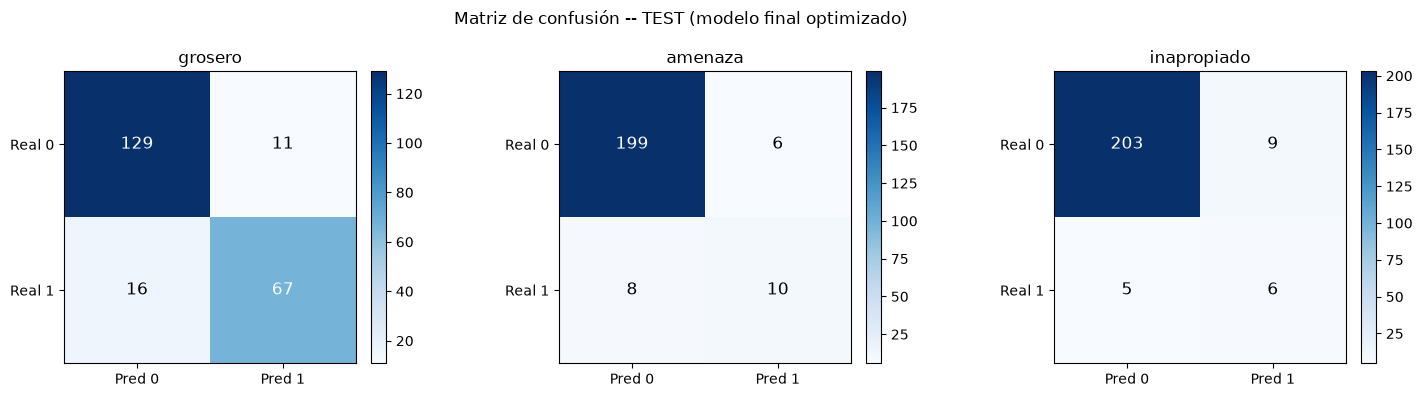

Heatmap guardado en: c:\Users\unvat\Downloads\treasureflow-nlp\training\notebooks\artifacts\matriz_confusion_heatmap.png


In [19]:
import matplotlib.pyplot as plt


def graficar_heatmap_matrices_confusion(matrices, nombre_split):
    """Dibuja un heatmap 2x2 por categoria a partir de las matrices ya
    calculadas por mostrar_matrices_confusion (mismo dato, complementa la
    version en texto plano). Guarda la figura en artifacts/ y la muestra.
    """
    fig, ejes = plt.subplots(1, len(LABEL_COLUMNS), figsize=(5 * len(LABEL_COLUMNS), 4))
    if len(LABEL_COLUMNS) == 1:
        ejes = [ejes]

    columnas = ["Pred 0", "Pred 1"]
    filas = ["Real 0", "Real 1"]

    for ax, nombre, matriz in zip(ejes, LABEL_COLUMNS, matrices):
        im = ax.imshow(matriz, cmap="Blues")

        ax.set_xticks(range(2))
        ax.set_xticklabels(columnas)
        ax.set_yticks(range(2))
        ax.set_yticklabels(filas)
        ax.set_title(nombre)

        # Texto blanco sobre celdas oscuras, negro sobre celdas claras.
        valor_medio = matriz.max() / 2
        for fila in range(2):
            for col in range(2):
                valor = matriz[fila, col]
                color_texto = "white" if valor > valor_medio else "black"
                ax.text(col, fila, str(valor), ha="center", va="center",
                        color=color_texto, fontsize=12)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"Matriz de confusión -- {nombre_split}")
    fig.tight_layout()

    ruta_heatmap = ARTIFACTS_DIR / "matriz_confusion_heatmap.png"
    fig.savefig(ruta_heatmap, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Heatmap guardado en: {ruta_heatmap}")


graficar_heatmap_matrices_confusion(matrices_test, "TEST (modelo final optimizado)")

## Resumen final: búsqueda de hiperparámetros y resultado en test

**Mejores hiperparámetros encontrados por Optuna** (`N_TRIALS` trials,
métrica optimizada = mínimo de los tres F1 por categoría en `validation`,
no el promedio): los valores exactos de `tope_amenaza`, `tope_inapropiado`,
`learning_rate` y `num_epochs` quedan impresos en `study.best_params` al
final de la celda de búsqueda, junto con `study.best_value` y las métricas
completas del mejor trial. `tope_grosero` se dejó fijo en 3.0 en todos los
trials, ya que se mostró estable en rondas anteriores y no ameritaba
búsqueda.

**Métricas finales en TEST** del modelo reentrenado desde cero con esos
hiperparámetros: ver la salida impresa de `resultados_test_final` en la
celda de entrenamiento final, y el detalle por categoría en las matrices
de confusión, guardadas también en
`training/notebooks/artifacts/matriz_confusion_final.txt`.

**Nota honesta sobre varianza:** dado el tamaño limitado del dataset en
las categorías minoritarias (amenaza, inapropiado — decenas de ejemplos,
no miles), es esperable que estas métricas cambien de una corrida a otra
incluso con semillas fijas, simplemente por cómo caen los pocos ejemplos
positivos disponibles en cada split. Estos números deben leerse como una
estimación razonable del comportamiento del modelo, no como un valor
exacto e inmutable — antes de confiar fuertemente en ellos para
producción conviene monitorear el desempeño real y, si es posible, seguir
ampliando el dataset de estas dos categorías.

## **Barrido de umbrales**

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score
import torch

predicciones = trainer.predict(dataset_tokenizado["test"])
probs = torch.sigmoid(torch.tensor(predicciones.predictions)).numpy()
labels_reales = predicciones.label_ids

idx_inapropiado = LABEL_COLUMNS.index("inapropiado")
probs_inapropiado = probs[:, idx_inapropiado]
labels_inapropiado = labels_reales[:, idx_inapropiado]

print(f"{'Umbral':>8} {'Precisión':>10} {'Recall':>8} {'F1':>8}")
for umbral in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    preds = (probs_inapropiado > umbral).astype(int)
    p = precision_score(labels_inapropiado, preds, zero_division=0)
    r = recall_score(labels_inapropiado, preds, zero_division=0)
    f = f1_score(labels_inapropiado, preds, zero_division=0)
    print(f"{umbral:>8.2f} {p:>10.3f} {r:>8.3f} {f:>8.3f}")

  Umbral  Precisión   Recall       F1
    0.10      0.261    0.545    0.353
    0.15      0.294    0.455    0.357
    0.20      0.312    0.455    0.370
    0.25      0.333    0.364    0.348
    0.30      0.333    0.364    0.348
    0.35      0.444    0.364    0.400
    0.40      0.429    0.273    0.333


## **Validación externa (dataset no visto durante el entrenamiento)**

El split `test_2` (agregado arriba en `data_files`, en la celda de
carga de datos) corresponde a
`training/data/processed/validacion_externa_moderacion_completo.csv`
-- un dataset separado del train/validation/test usados en el
entrenamiento y la búsqueda de hiperparámetros, para medir
generalización real sobre texto que el modelo nunca vio.

Como la celda de tokenización aplica `dataset.map(...)` sobre TODO
el `DatasetDict` (todos los splits, incluido `test_2`),
`dataset_tokenizado["test_2"]` ya queda listo para usarse con el
mismo `trainer` ya entrenado -- sin recargar nada desde disco ni
reentrenar.

Matrices de confusion -- split: VALIDACION EXTERNA

--- grosero ---
        Pred 0   Pred 1
Real 0     380       20
Real 1      27       73

--- amenaza ---
        Pred 0   Pred 1
Real 0     419        1
Real 1      18       62

--- inapropiado ---
        Pred 0   Pred 1
Real 0     423        7
Real 1      55       15

Matrices guardadas en: c:\Users\unvat\Downloads\treasureflow-nlp\training\notebooks\artifacts\matriz_confusion_validacion_externa.txt


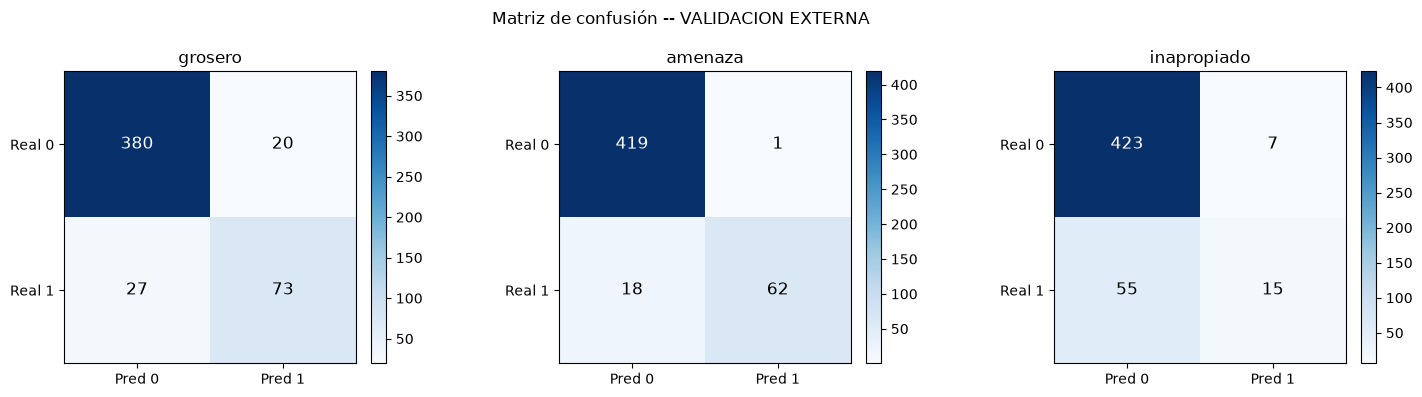

Heatmap guardado en: c:\Users\unvat\Downloads\treasureflow-nlp\training\notebooks\artifacts\matriz_confusion_heatmap.png


In [21]:
texto_matrices_validacion_externa, matrices_validacion_externa = mostrar_matrices_confusion(
    trainer, dataset_tokenizado["test_2"], "VALIDACION EXTERNA"
)

ruta_matriz_validacion_externa = ARTIFACTS_DIR / "matriz_confusion_validacion_externa.txt"
ruta_matriz_validacion_externa.write_text(texto_matrices_validacion_externa, encoding="utf-8")
print(f"\nMatrices guardadas en: {ruta_matriz_validacion_externa}")

graficar_heatmap_matrices_confusion(matrices_validacion_externa, "VALIDACION EXTERNA")

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score
import torch

predicciones = trainer.predict(dataset_tokenizado["test_2"])
probs = torch.sigmoid(torch.tensor(predicciones.predictions)).numpy()
labels_reales = predicciones.label_ids

for nombre_categoria in ["grosero", "amenaza", "inapropiado"]:
    idx = LABEL_COLUMNS.index(nombre_categoria)
    probs_cat = probs[:, idx]
    labels_cat = labels_reales[:, idx]

    print(f"\n=== {nombre_categoria} ===")
    print(f"{'Umbral':>8} {'Precisión':>10} {'Recall':>8} {'F1':>8}")
    for umbral in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:
        preds = (probs_cat > umbral).astype(int)
        p = precision_score(labels_cat, preds, zero_division=0)
        r = recall_score(labels_cat, preds, zero_division=0)
        f = f1_score(labels_cat, preds, zero_division=0)
        print(f"{umbral:>8.2f} {p:>10.3f} {r:>8.3f} {f:>8.3f}")


=== grosero ===
  Umbral  Precisión   Recall       F1
    0.05      0.513    0.960    0.669
    0.10      0.560    0.930    0.699
    0.15      0.618    0.890    0.730
    0.20      0.677    0.880    0.765
    0.25      0.703    0.830    0.761
    0.30      0.717    0.810    0.761
    0.35      0.750    0.780    0.765
    0.40      0.750    0.750    0.750
    0.50      0.785    0.730    0.756
    0.55      0.800    0.720    0.758
    0.60      0.798    0.710    0.751
    0.65      0.854    0.700    0.769
    0.70      0.885    0.690    0.775
    0.75      0.892    0.660    0.759
    0.80      0.900    0.630    0.741

=== amenaza ===
  Umbral  Precisión   Recall       F1
    0.05      0.517    0.950    0.670
    0.10      0.682    0.938    0.789
    0.15      0.758    0.900    0.823
    0.20      0.855    0.887    0.871
    0.25      0.872    0.850    0.861
    0.30      0.918    0.838    0.876
    0.35      0.944    0.838    0.887
    0.40      0.955    0.800    0.871
    0.50      0.